<a href="https://colab.research.google.com/github/muhammad-faizan087/Machine-Learning-Projects/blob/main/Classification%20Algorithms/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv(r'/content/drive/MyDrive/heart.csv')

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.shape

(918, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

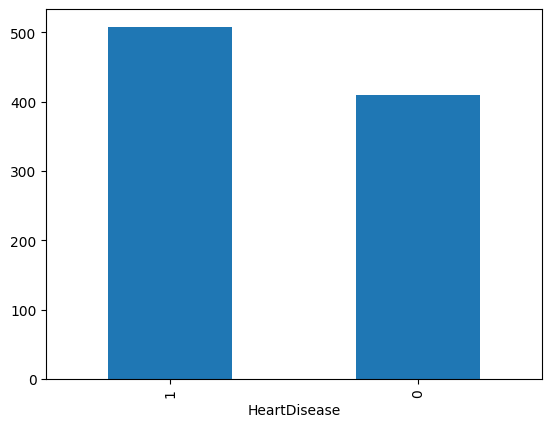

In [10]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [11]:
def plotting(col, num):
  plt.subplot(2,2,num)
  sns.histplot(df[col], kde=True)

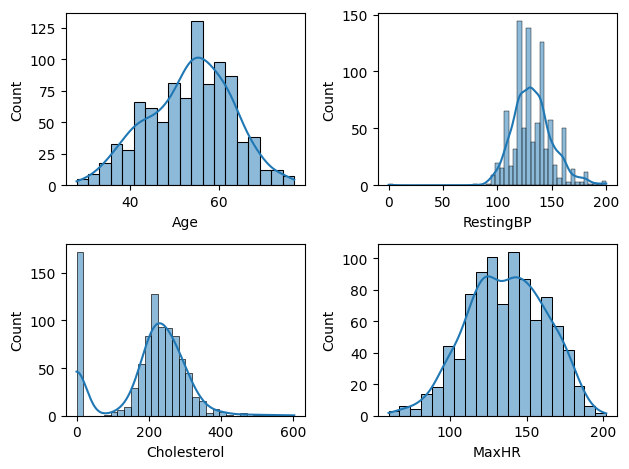

In [12]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
# plotting('FastingBS',4)
plotting('MaxHR',4)
# plotting('Oldpeak',6)
plt.tight_layout()

# Some Key Points

- Earlier we saw that the data didn't had any duplicates or null values but data cleaning isn't only that, here we can see that some logical errors are there in the data like a person can't have 0 Resting BP and Cholestrol so we need to correct it.

In [13]:
df.loc[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [14]:
df.drop(df.loc[df['RestingBP'] == 0].index, inplace=True)

In [15]:
ch_mean = df[df['Cholesterol'] != 0]['Cholesterol'].mean()

In [16]:
ch_mean

np.float64(244.6353887399464)

In [17]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)

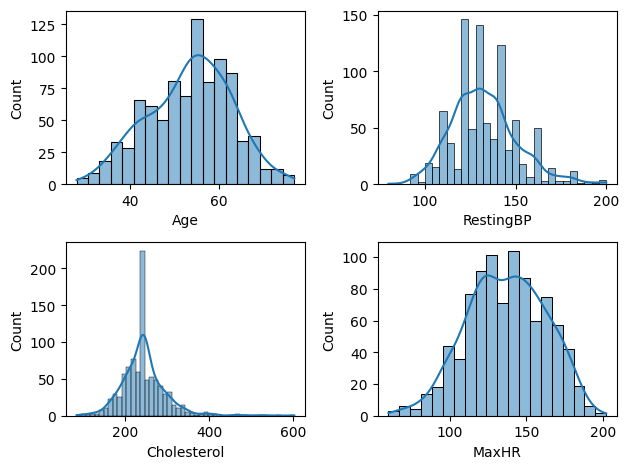

In [18]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [19]:
pip install sheryanalysis

In [20]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (917, 12)


...


🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']


INFO:sheryanalysis:
🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']



🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (917, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('int64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 917,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Restin

<Axes: xlabel='Sex', ylabel='count'>

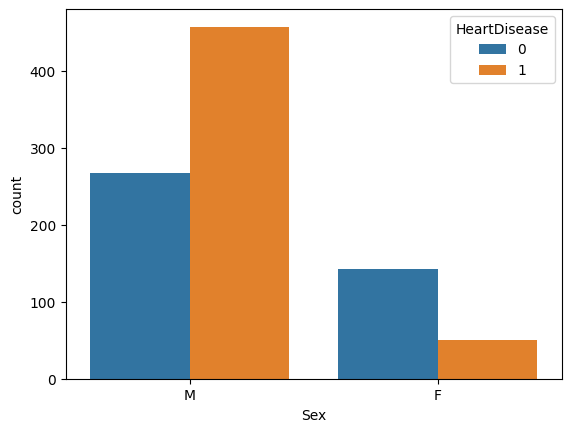

In [21]:
sns.countplot(x= df['Sex'], hue=df['HeartDisease'])

Indicating that males have more chances of getting heartDisease and women have more chances of not getting

<Axes: xlabel='ChestPainType', ylabel='count'>

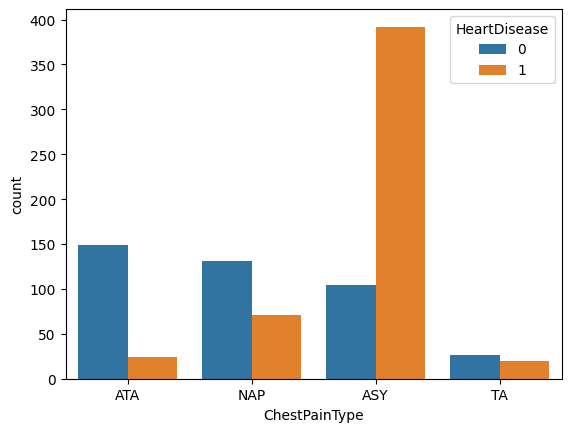

In [22]:
sns.countplot(x = df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

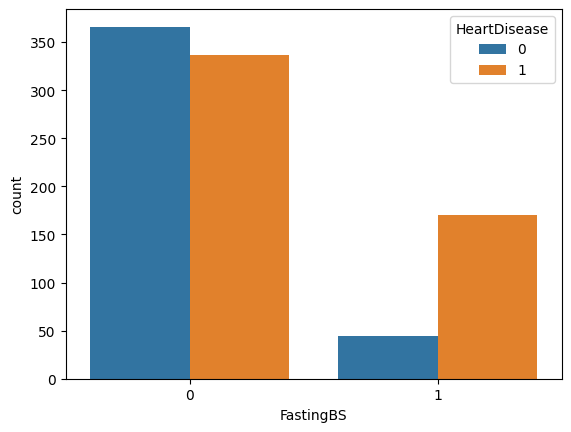

In [23]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

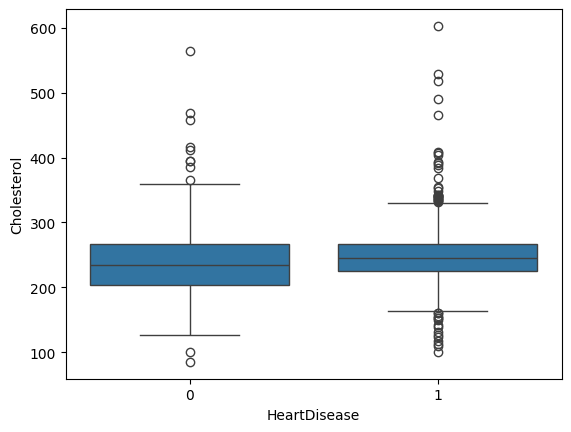

In [24]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

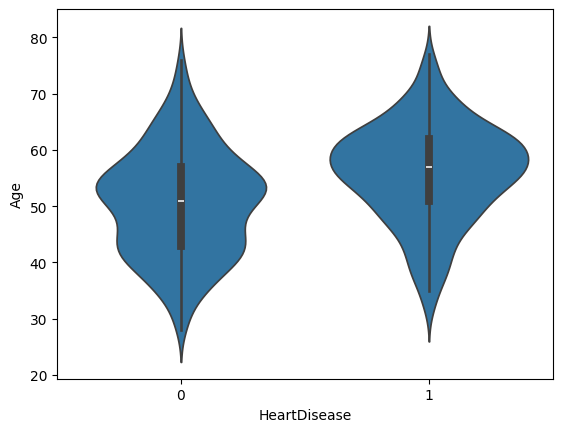

In [25]:
sns.violinplot(x = 'HeartDisease', y = 'Age',data = df)

<Axes: >

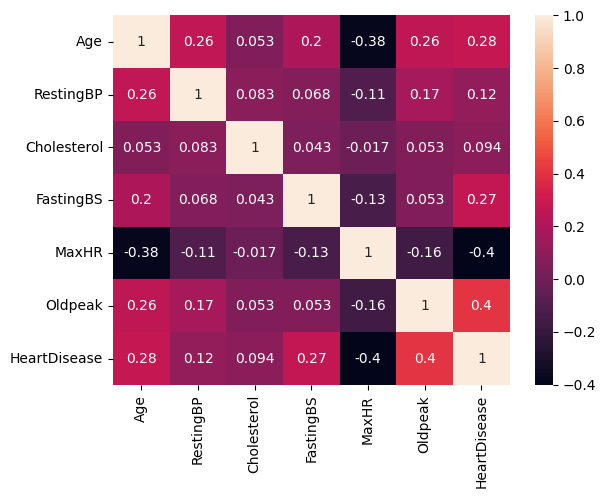

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data perprocessing

We can direct encode the whole df at once instead of doing each seperately

In [27]:
df_encode = pd.get_dummies(df, drop_first=True)

In [28]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [29]:
df_encode = df_encode.astype(int)

In [30]:
df_unscaled = df_encode.copy()

# Feature Extraction

In [31]:
from scipy.stats import chi2_contingency

In [32]:
alpha = 0.05
cat_vars = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
chi2_results = {}
for col in cat_vars:
  contingency_table = pd.crosstab(df[col], df['HeartDisease'])
  chi2, p_val, _ , _ = chi2_contingency(contingency_table)
  result = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
  chi2_results[col] = {'Chi2': chi2, 'p_value': p_val,'Decision':result }
df_chi2 = pd.DataFrame(chi2_results).T
df_chi2

,Chi2,p_value,Decision
Sex,83.871151,0.0,Reject Null (Keep Feature)
ChestPainType,268.896258,0.0,Reject Null (Keep Feature)
FastingBS,64.591342,0.0,Reject Null (Keep Feature)
RestingECG,11.069537,0.003947,Reject Null (Keep Feature)
ExerciseAngina,223.107207,0.0,Reject Null (Keep Feature)
ST_Slope,355.155699,0.0,Reject Null (Keep Feature)


In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.432206,0.414627,0.834288,0,1.383339,-0.726919,0,1,1,0,0,1,0,0,0,1
1,-0.478057,1.526360,-1.210026,0,0.754736,0.283058,1,0,0,1,0,1,0,0,1,0
2,-1.750256,-0.141240,0.721757,0,-1.523953,-0.726919,0,1,1,0,0,0,1,0,0,1
3,-0.584074,0.303453,-0.572350,0,-1.131075,0.283058,1,0,0,0,0,1,0,1,1,0
4,0.052026,0.970493,-0.928698,0,-0.581047,-0.726919,0,1,0,1,0,1,0,0,0,1


Since only 1 column that can be dropped which is cholestrol but for now let's consider that also

In [35]:
X_scaled = df_encode.drop(['HeartDisease'], axis=1)
Y = df_encode['HeartDisease']

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
X_train_scaled, X_test_scaled, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [39]:
models = {'Logistic Regression': LogisticRegression(), 'KNN':KNeighborsClassifier(), 'Naive Bayes':GaussianNB(),
         'SVM':SVC(), 'Decision Trees':DecisionTreeClassifier()}

In [40]:
from sklearn.metrics import f1_score # Re-import f1_score to ensure function is used

result = []
for name, model in models.items():
  model.fit(X_train_scaled, Y_train)
  Y_pred = model.predict(X_test_scaled)
  acc = accuracy_score(Y_test,Y_pred)
  f1 = f1_score(Y_test, Y_pred)
  result.append({'model':name, 'accuracy':acc, 'f1_score':f1})

In [41]:
result

[{'model': 'Logistic Regression',
  'accuracy': 0.875,
  'f1_score': 0.8940092165898618},
 {'model': 'KNN',
  'accuracy': 0.8315217391304348,
  'f1_score': 0.8571428571428571},
 {'model': 'Naive Bayes',
  'accuracy': 0.8260869565217391,
  'f1_score': 0.8461538461538461},
 {'model': 'SVM',
  'accuracy': 0.8478260869565217,
  'f1_score': 0.8715596330275229},
 {'model': 'Decision Trees',
  'accuracy': 0.717391304347826,
  'f1_score': 0.7592592592592593}]

In [42]:
df_unscaled.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [43]:
X_unscaled = df_unscaled.drop(['HeartDisease'], axis=1)

In [44]:
X_train_unscaled, X_test_unscaled, Y_train, Y_test = train_test_split(X_unscaled, Y, test_size=0.2, random_state=42)

In [45]:
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train_unscaled, Y_train)


DecisionTreeClassifier()

In [46]:
Y_pred = model_DT.predict(X_test_unscaled)

In [47]:
accuracy_score(Y_test,Y_pred)


0.7336956521739131

# Conclusion:

- Out of all the 5 algos, Logistic Reg is performing the best so we'll use that for predictions

In [48]:
import joblib

In [49]:
joblib.dump(models['Logistic Regression'], 'model_heart_disease.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_scaled.columns.tolist(), 'columns.pkl')


['columns.pkl']